Train shape: (541292, 155)
Insurers: ['Insurer_A', 'Insurer_B', 'Insurer_C', 'Insurer_D', 'Insurer_E', 'Insurer_F', 'Insurer_G', 'Insurer_H', 'Insurer_I', 'Insurer_J', 'Insurer_K']
['quote_id', 'vehicle_ownership_duration', 'vehicle_number_plate', 'coverage', 'claim_free_years', 'payment_frequency', 'contractor_birthdate', 'is_driver_owner', 'usage', 'second_driver_birthdate', 'second_driver_claim_free_years', 'vehicle_maker', 'vehicle_model', 'vehicle_fuel_type', 'vehicle_engine_size', 'vehicle_power', 'vehicle_net_weight', 'vehicle_gross_weight', 'vehicle_length', 'vehicle_width', 'vehicle_height', 'vehicle_number_of_cylinders', 'vehicle_number_of_doors', 'vehicle_number_of_seats', 'vehicle_number_of_wheels', 'vehicle_primary_color', 'vehicle_value_new', 'vehicle_net_max_power', 'vehicle_net_max_power_electric', 'vehicle_nominal_continuous_max_power', 'vehicle_power_to_net_weight_ratio', 'vehicle_age', 'vehicle_first_registration_date', 'vehicle_country_first_registration_date', 'veh

/tmp/ipykernel_163883/1210999302.py:42: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['car_age'] = (anchor - pd.to_datetime(df['vehicle_first_registration_date'], errors='coerce')).dt.days / 365.25


-> Alarmi za iskustvo (Iskustvo > Starost-15): 0 redova
-> Alarmi za 'putnike kroz vreme' (negativna starost): 0 redova
-> Alarmi za cene (Nula ili negativne cene): 0


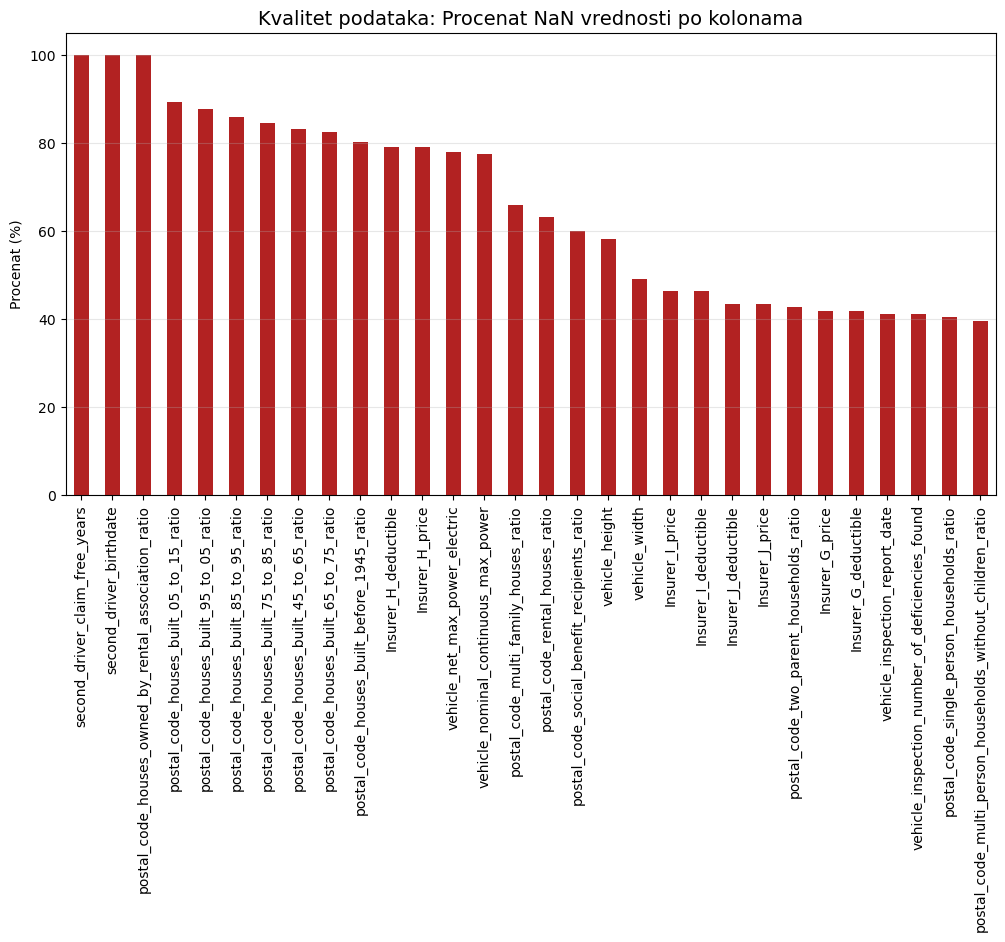

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_raw = pd.read_parquet('datasets/block1_train.parquet', engine='fastparquet')


insurer_cols = [c for c in train_raw.columns if c.endswith('_price')]
insurers = [c.replace('_price', '') for c in insurer_cols]

print(f"Train shape: {train_raw.shape}")
print(f"Insurers: {insurers}")

print(train_raw.columns.tolist())


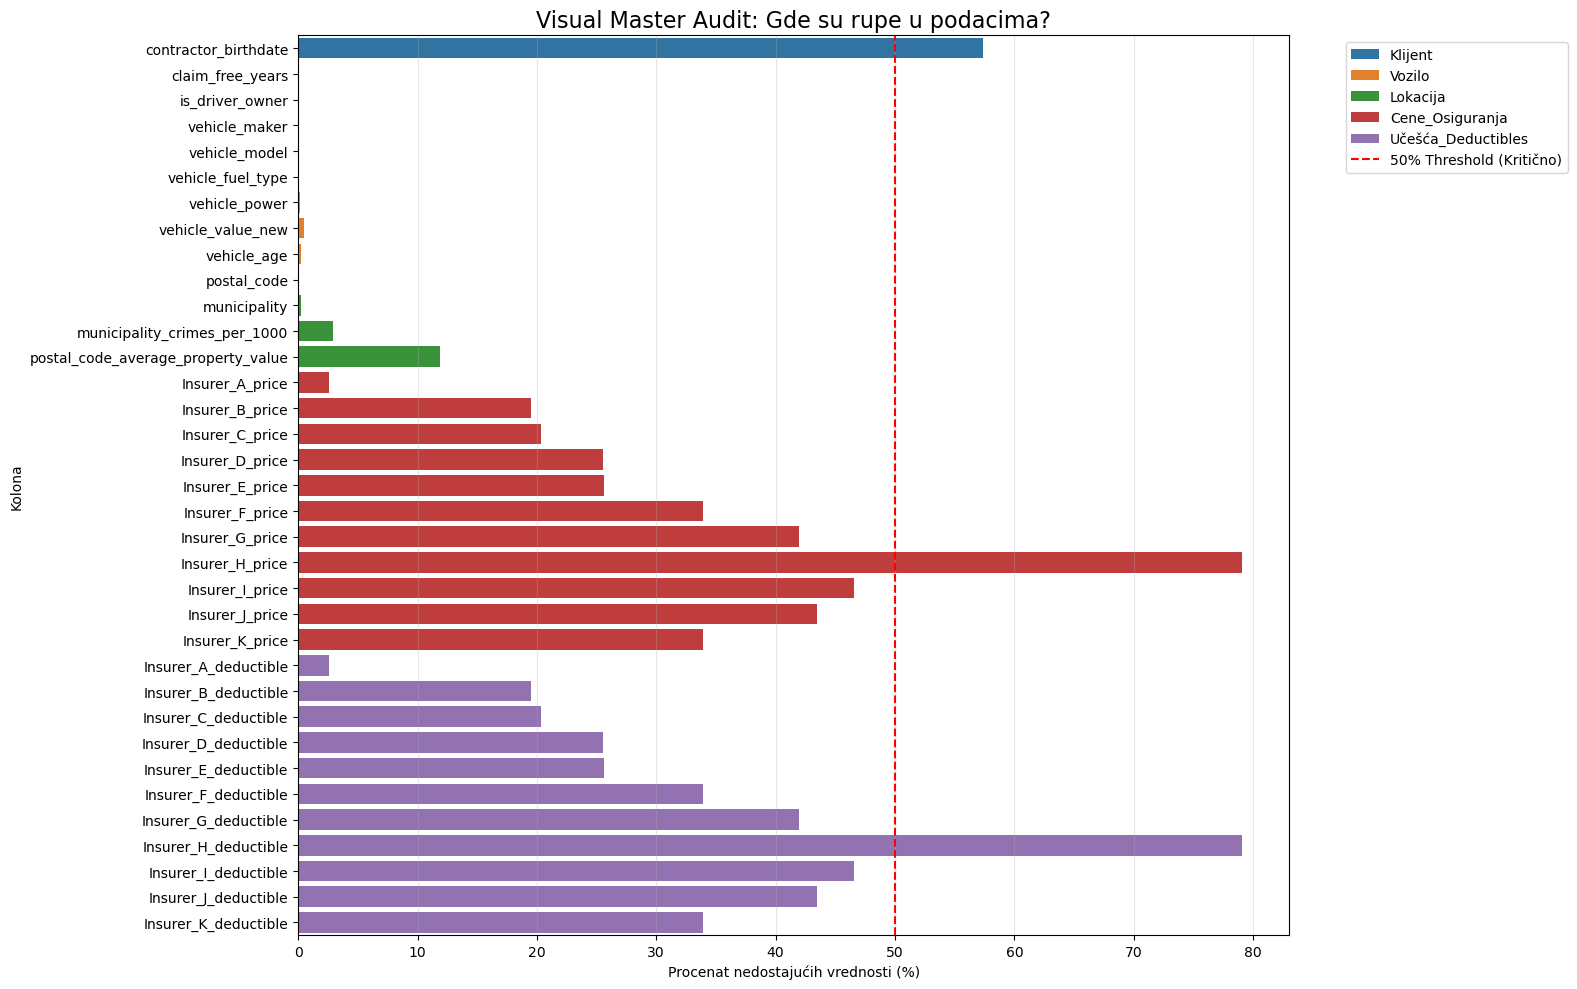

=== LOGIČKI SKENER REZULTATI ===
1. Nemoguće iskustvo (Iskustvo > Godine-17): 0 redova
2. Vozila sa nerealnom vrednošću (<=100): 0 redova

=== KATEGORIČKA KARDINALNOST (Unikati) ===
- vehicle_maker: 119 unikata
- vehicle_model: 1055 unikata
- postal_code: 90 unikata
- municipality: 360 unikata


In [5]:
def visual_master_audit(df):
    # 1. ČIŠĆENJE I KONVERZIJA (Fundamentalni korak)
    # Datumi
    date_cols = ['contractor_birthdate', 'vehicle_first_registration_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Numerici (uključujući cene i učešća)
    price_cols = [c for c in df.columns if '_price' in c]
    deduct_cols = [c for c in df.columns if '_deductible' in c]
    core_nums = ['claim_free_years', 'vehicle_value_new', 'vehicle_power', 'municipality_crimes_per_1000']
    
    for col in price_cols + deduct_cols + core_nums:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 2. GRUPISANJE KOLONA ZA VIZUELIZACIJU
    groups = {
        'Klijent': ['contractor_birthdate', 'claim_free_years', 'is_driver_owner'],
        'Vozilo': ['vehicle_maker', 'vehicle_model', 'vehicle_fuel_type', 'vehicle_power', 'vehicle_value_new', 'vehicle_age'],
        'Lokacija': ['postal_code', 'municipality', 'municipality_crimes_per_1000', 'postal_code_average_property_value'],
        'Cene_Osiguranja': price_cols,
        'Učešća_Deductibles': deduct_cols
    }

    # Računanje missing vrednosti po grupama
    group_data = []
    for g_name, g_cols in groups.items():
        for col in g_cols:
            if col in df.columns:
                group_data.append({
                    'Grupa': g_name,
                    'Kolona': col,
                    'Missing_%': df[col].isnull().mean() * 100
                })
    
    plot_df = pd.DataFrame(group_data)

    # 3. GRAFIK 1: MISSING DATA HEATMAP (Po grupama)
    plt.figure(figsize=(16, 10))
    sns.barplot(data=plot_df, x='Missing_%', y='Kolona', hue='Grupa', dodge=False)
    plt.axvline(50, color='red', linestyle='--', label='50% Threshold (Kritično)')
    plt.title('Visual Master Audit: Gde su rupe u podacima?', fontsize=16)
    plt.xlabel('Procenat nedostajućih vrednosti (%)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4. LOGIČKI SKENER (Kvalitet unutar popunjenih podataka)
    anchor = pd.to_datetime('2025-12-27')
    df['driver_age'] = (anchor - df['contractor_birthdate']).dt.days / 365.25
    
    # Anomalije
    bad_logic_age = df[(df['claim_free_years'] > (df['driver_age'] - 17)) & df['driver_age'].notnull()].shape[0]
    zero_val_cars = df[df['vehicle_value_new'] <= 100].shape[0]
    
    print("=== LOGIČKI SKENER REZULTATI ===")
    print(f"1. Nemoguće iskustvo (Iskustvo > Godine-17): {bad_logic_age} redova")
    print(f"2. Vozila sa nerealnom vrednošću (<=100): {zero_val_cars} redova")
    
    # 5. KARDINALNOST (Unique Values za kategorike)
    cat_cols = ['vehicle_maker', 'vehicle_model', 'fuel_type', 'postal_code', 'municipality']
    print("\n=== KATEGORIČKA KARDINALNOST (Unikati) ===")
    for col in cat_cols:
        if col in df.columns:
            print(f"- {col}: {df[col].nunique()} unikata")

# Pokreni audit
visual_master_audit(train_raw)

=== UTICAJ POSTOJANJA DATUMA ROĐENJA NA CENU ===
               Insurer_A_price  Insurer_H_price  claim_free_years
has_birthdate                                                    
0                    96.720444       116.140204          6.285402
1                    97.122515       116.017211          6.166628


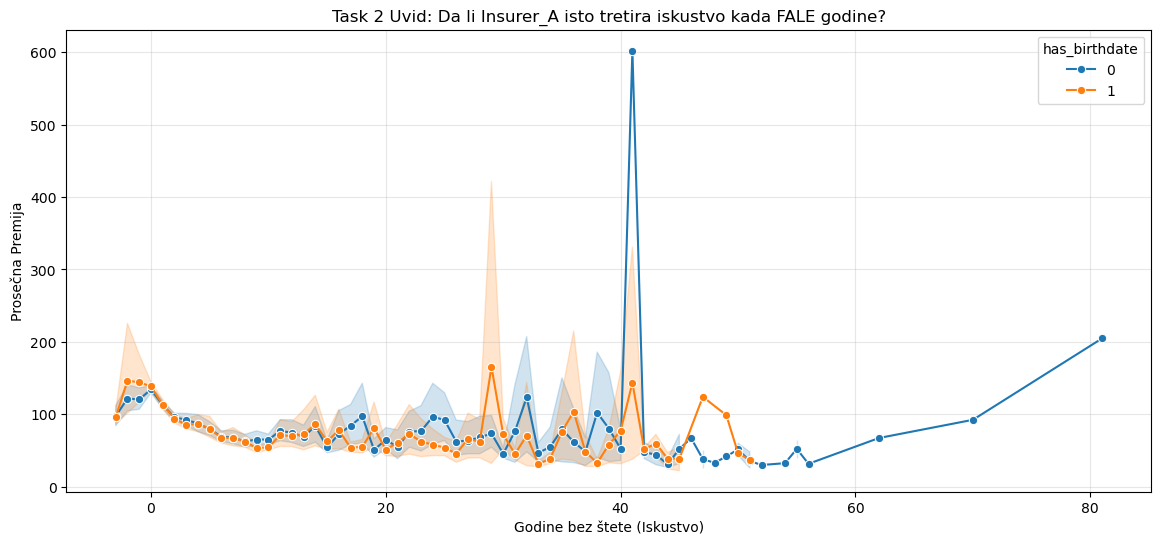

In [7]:
# 1. Kreiramo flag: Da li imamo datum rođenja?
train_raw['has_birthdate'] = train_raw['contractor_birthdate'].notnull().astype(int)

# 2. Analiziramo prosečnu cenu kod Insurer_A (najagresivniji) i Insurer_H (najizbirljiviji)
# u zavisnosti od toga da li podatak postoji
comparison_cols = ['Insurer_A_price', 'Insurer_H_price', 'claim_free_years']

age_impact = train_raw.groupby('has_birthdate')[comparison_cols].mean()

print("=== UTICAJ POSTOJANJA DATUMA ROĐENJA NA CENU ===")
print(age_impact)

# 3. VIZUELIZACIJA: Da li iskustvo diktira cenu isto u obe grupe?
plt.figure(figsize=(14, 6))

# Uzimamo uzorak da grafikon ne bude preopterećen
sample_df = train_raw.sample(20000, random_state=42)

sns.lineplot(data=sample_df, x='claim_free_years', y='Insurer_A_price', 
             hue='has_birthdate', marker='o')

plt.title('Task 2 Uvid: Da li Insurer_A isto tretira iskustvo kada FALE godine?')
plt.xlabel('Godine bez štete (Iskustvo)')
plt.ylabel('Prosečna Premija')
plt.grid(True, alpha=0.3)
plt.show()

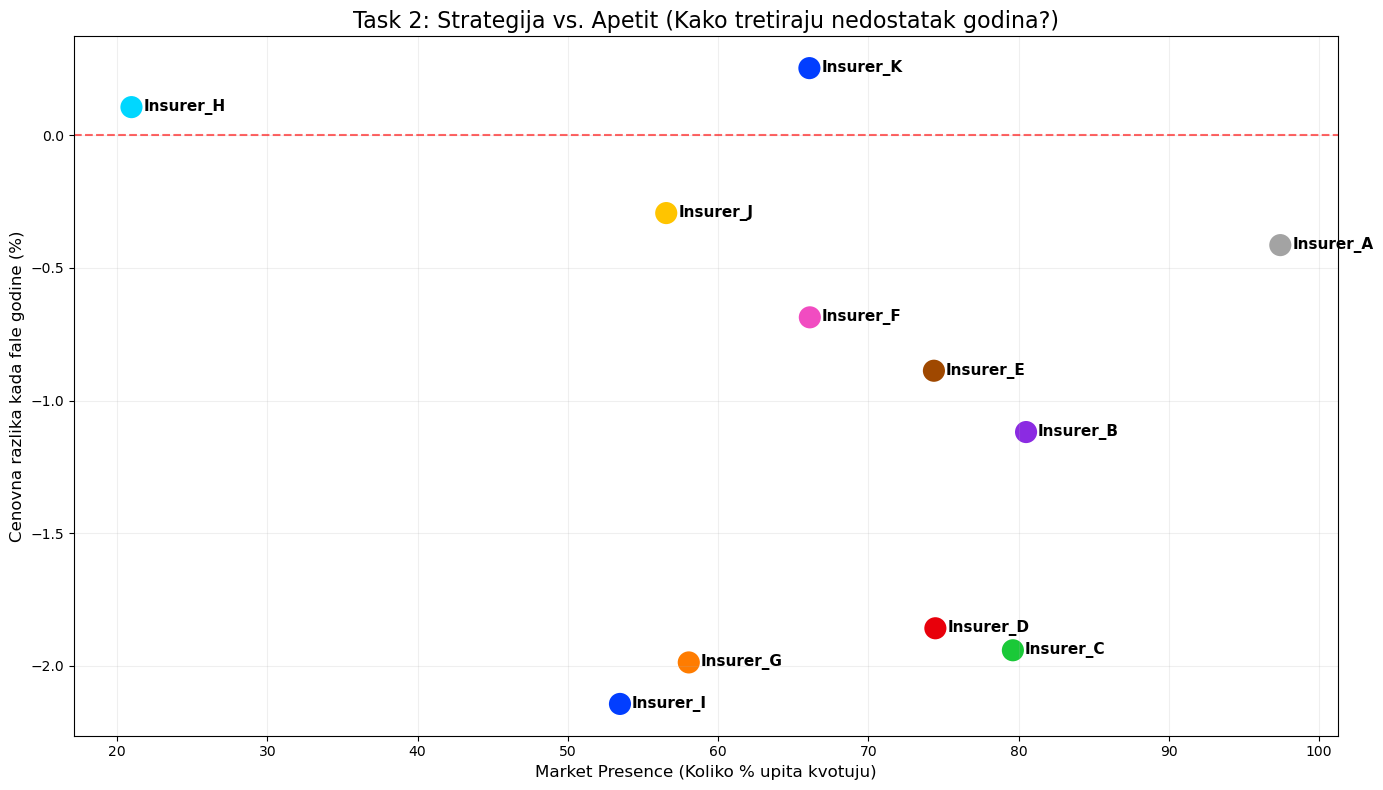

Analiza završena. Pogledaj ko se nalazi u gornjem delu (kažnjavaju nepoznato), a ko dole (nude popust).


In [10]:
# 1. Izračunavamo razliku u ceni i prisustvo za SVAKOG osiguravača
market_analysis = []

for ins in insurers:
    price_col = f'{ins}_price'
    
    # Provera da li osiguravač uopšte ima podatke (da izbegnemo ZeroDivision)
    if train_raw[price_col].notnull().any():
        # Prosečna cena sa i bez datuma rođenja
        mean_with = train_raw[train_raw['has_birthdate'] == 1][price_col].mean()
        mean_without = train_raw[train_raw['has_birthdate'] == 0][price_col].mean()
        
        # Razlika u procentima (koliko skuplje/jeftinije naplaćuju kad FALE godine)
        diff_pct = ((mean_without - mean_with) / mean_with) * 100
        
        # Koliko upita zapravo kvotuju (Market Apetite)
        quote_rate = train_raw[price_col].notnull().mean() * 100
        
        market_analysis.append({
            'Insurer': ins,
            'Price_Diff_Pct': diff_pct,
            'Market_Presence_Pct': quote_rate
        })

market_df = pd.DataFrame(market_analysis).sort_values(by='Price_Diff_Pct')

# 2. VIZUELIZACIJA
plt.figure(figsize=(14, 8))
# Koristimo scatterplot sa labelama
sns.scatterplot(data=market_df, x='Market_Presence_Pct', y='Price_Diff_Pct', 
                hue='Insurer', s=300, palette='bright', legend=False)

plt.axhline(0, color='red', linestyle='--', alpha=0.6)
plt.title('Task 2: Strategija vs. Apetit (Kako tretiraju nedostatak godina?)', fontsize=16)
plt.xlabel('Market Presence (Koliko % upita kvotuju)', fontsize=12)
plt.ylabel('Cenovna razlika kada fale godine (%)', fontsize=12)

# Popravljen deo za ispis imena pored tačaka
for i in range(market_df.shape[0]):
    plt.text(market_df['Market_Presence_Pct'].iloc[i] + 0.8, 
             market_df['Price_Diff_Pct'].iloc[i], 
             market_df['Insurer'].iloc[i], 
             fontsize=11, fontweight='bold', va='center')

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Analiza završena. Pogledaj ko se nalazi u gornjem delu (kažnjavaju nepoznato), a ko dole (nude popust).")

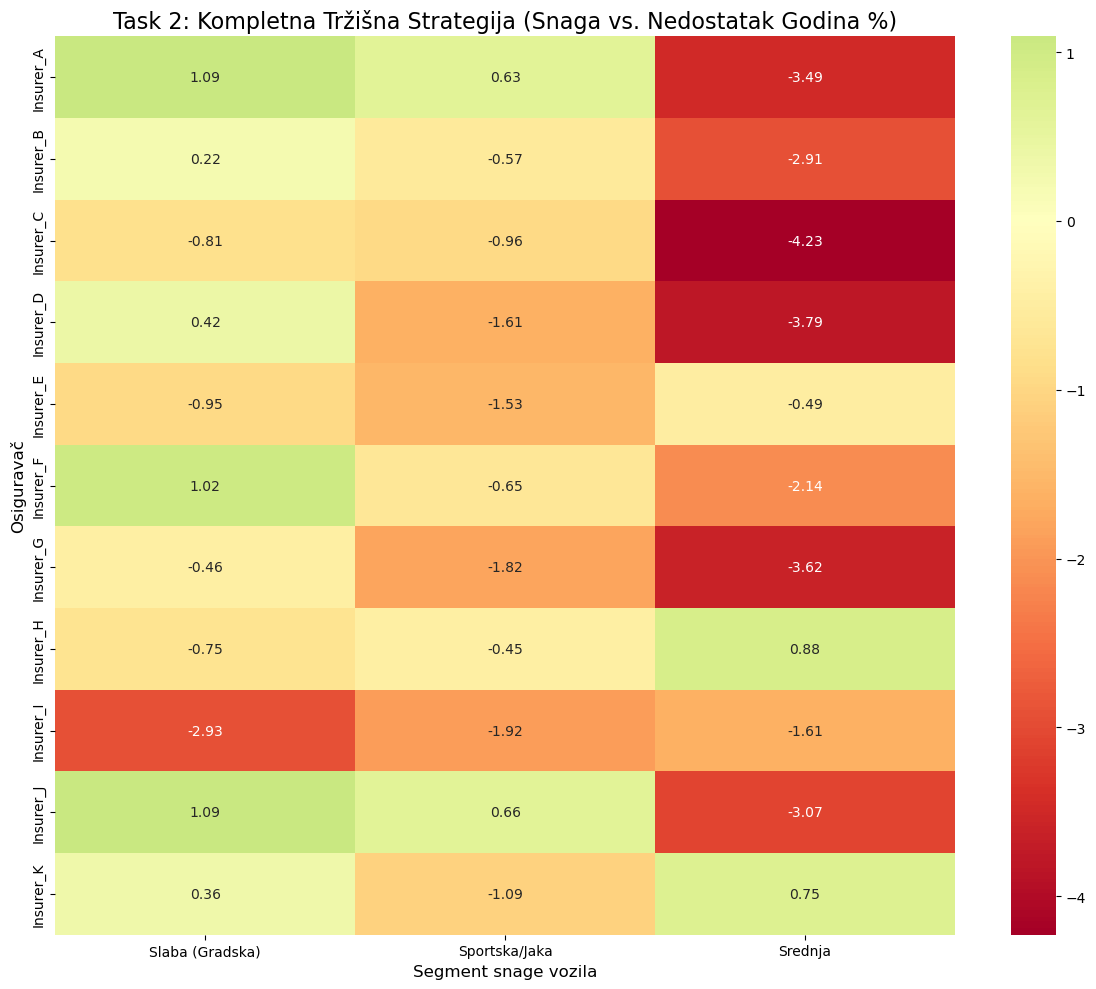

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PRIPREMA I ČIŠĆENJE (Senior nivo - ne pretpostavljamo da su podaci čisti)
train_raw['vehicle_power'] = pd.to_numeric(train_raw['vehicle_power'], errors='coerce')
train_raw['has_birthdate'] = train_raw['contractor_birthdate'].notnull().astype(int)

# Izbacujemo NaN za snagu samo za ovu analizu
df_power = train_raw.dropna(subset=['vehicle_power']).copy()

# 2. SEGMENTACIJA SNAGE (Tertiles - delimo na 3 jednaka dela po broju upita)
df_power['power_segment'] = pd.qcut(df_power['vehicle_power'], 3, 
                                   labels=['Slaba (Gradska)', 'Srednja', 'Sportska/Jaka'])

# Spisak svih osiguravača (od A do K)
insurer_cols = [c for c in train_raw.columns if c.endswith('_price')]
insurers_all = [c.replace('_price', '') for c in insurer_cols]

# 3. TOTALNA ANALIZA
full_power_analysis = []

for ins in insurers_all:
    price_col = f'{ins}_price'
    
    # Provera da li osiguravač uopšte nudi cene u datasetu
    if price_col in df_power.columns and df_power[price_col].notnull().any():
        for seg in ['Slaba (Gradska)', 'Srednja', 'Sportska/Jaka']:
            subset = df_power[df_power['power_segment'] == seg]
            
            # Računamo proseke: sa datumom rođenja vs bez
            mean_with = subset[subset['has_birthdate'] == 1][price_col].mean()
            mean_without = subset[subset['has_birthdate'] == 0][price_col].mean()
            
            # Procenat razlike (Price Gap)
            if pd.notnull(mean_with) and pd.notnull(mean_without) and mean_with > 0:
                diff_pct = ((mean_without - mean_with) / mean_with) * 100
                full_power_analysis.append({
                    'Insurer': ins,
                    'Power_Segment': seg,
                    'Price_Diff_Pct': diff_pct
                })

power_full_df = pd.DataFrame(full_power_analysis)

# 4. VIZUELIZACIJA: Heatmap za "Market Intelligence"
pivot_power = power_full_df.pivot(index='Insurer', columns='Power_Segment', values='Price_Diff_Pct')

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_power, annot=True, fmt=".2f", cmap='RdYlGn', center=0)
plt.title('Task 2: Kompletna Tržišna Strategija (Snaga vs. Nedostatak Godina %)', fontsize=16)
plt.xlabel('Segment snage vozila', fontsize=12)
plt.ylabel('Osiguravač', fontsize=12)
plt.tight_layout()
plt.show()

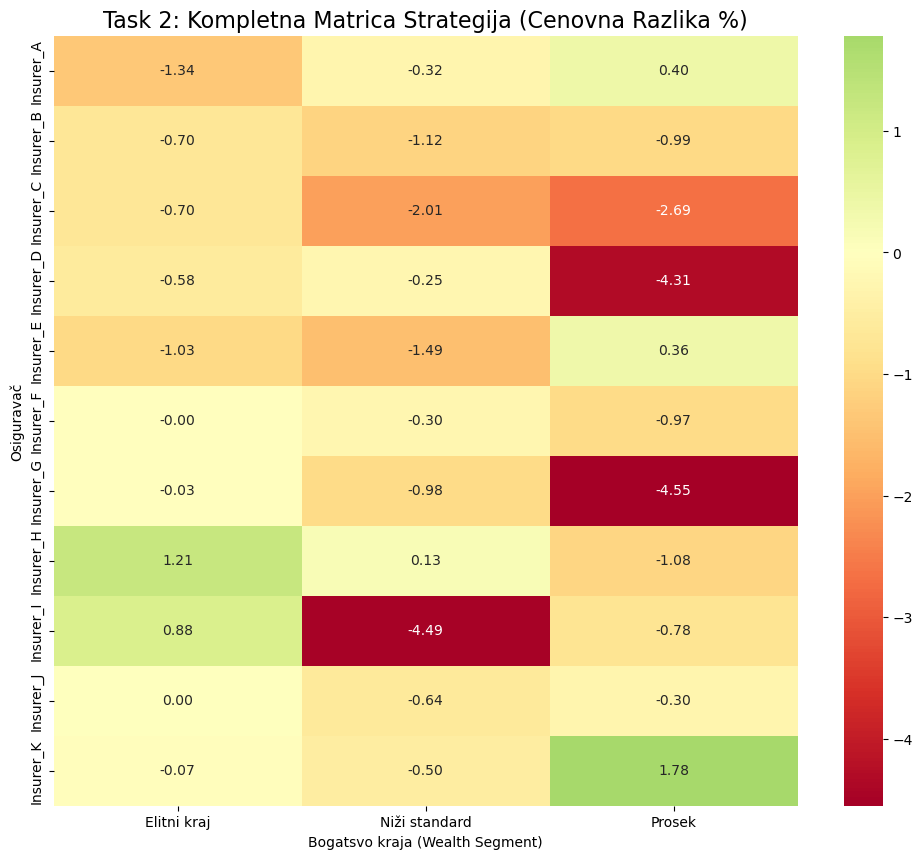

In [14]:
# 1. Osiguravamo da su podaci čisti (za svaki slučaj ponavljamo konverziju)
train_raw['postal_code_average_property_value'] = pd.to_numeric(
    train_raw['postal_code_average_property_value'].astype(str).str.replace(',', ''), 
    errors='coerce'
)
train_raw['postal_code_average_property_value'] = train_raw['postal_code_average_property_value'].fillna(
    train_raw['postal_code_average_property_value'].median()
)

# 2. Segmentacija na trećine
train_raw['wealth_segment'] = pd.qcut(
    train_raw['postal_code_average_property_value'], 3, 
    labels=['Niži standard', 'Prosek', 'Elitni kraj']
)

# 3. Analiza za SVE osiguravače
all_wealth_analysis = []
for ins in insurers:
    price_col = f'{ins}_price'
    # Provera da li osiguravač uopšte nudi cene
    if train_raw[price_col].notnull().any():
        for seg in ['Niži standard', 'Prosek', 'Elitni kraj']:
            subset = train_raw[train_raw['wealth_segment'] == seg]
            
            mean_with = subset[subset['has_birthdate'] == 1][price_col].mean()
            mean_without = subset[subset['has_birthdate'] == 0][price_col].mean()
            
            if pd.notnull(mean_with) and pd.notnull(mean_without):
                diff_pct = ((mean_without - mean_with) / mean_with) * 100
                all_wealth_analysis.append({
                    'Insurer': ins, 
                    'Wealth_Segment': seg, 
                    'Price_Diff_Pct': diff_pct
                })

wealth_full_df = pd.DataFrame(all_wealth_analysis)

# 4. Vizuelizacija: Heatmap (najbolji način za "temeljni" pregled svih odjednom)
pivot_wealth = wealth_full_df.pivot(index="Insurer", columns="Wealth_Segment", values="Price_Diff_Pct")

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_wealth, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title('Task 2: Kompletna Matrica Strategija (Cenovna Razlika %)', fontsize=16)
plt.xlabel('Bogatsvo kraja (Wealth Segment)')
plt.ylabel('Osiguravač')
plt.show()

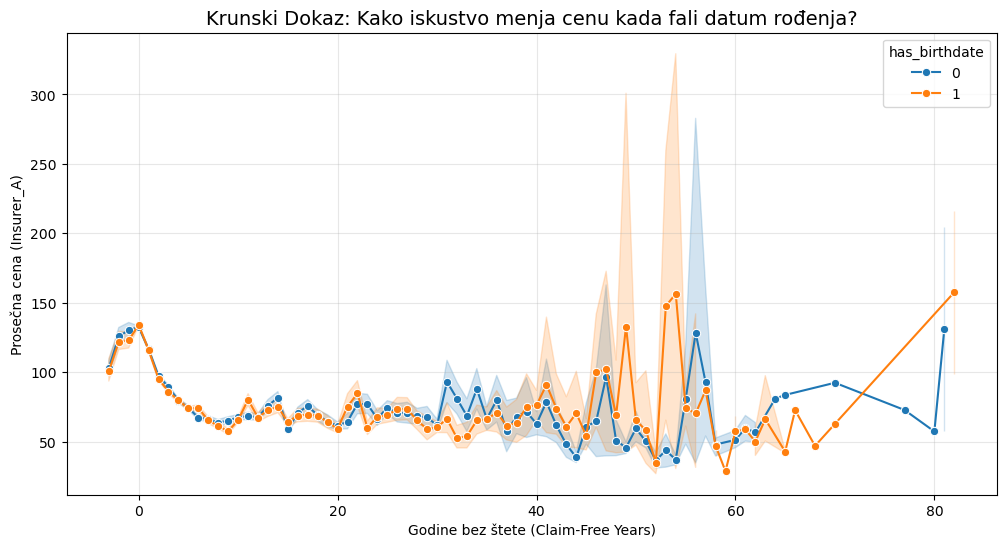

In [ ]:
# Gledamo odnos iskustva i cene kroz prizmu (ne)postojanja datuma rođenja
plt.figure(figsize=(12, 6))

# Uzimamo npr. Insurer_A kao reprezentativan primer
sns.lineplot(data=train_raw, x='claim_ free_years', y='Insurer_A_price', 
             hue='has_birthdate', marker='o')

plt.title('Krunski Dokaz: Kako iskustvo menja cenu kada fali datum rođenja?', fontsize=14)
plt.ylabel('Prosečna cena (Insurer_A)')
plt.xlabel('Godine bez štete (Claim-Free Years)')
plt.grid(True, alpha=0.3)
plt.show()